#  Loan Approval Prediction using Ensemble Learning

##  Project Overview

This project predicts whether a loan application will be approved using multiple Machine Learning classification algorithms, with a focus on Ensemble Learning techniques.

The notebook demonstrates a complete end-to-end Machine Learning workflow including:

- Exploratory Data Analysis (EDA)
- Data Cleaning
- Feature Engineering
- Data Preprocessing Pipeline
- Model Comparison
- Hyperparameter Tuning
- Model Explainability

The objective is to compare different ensemble models and identify the best-performing classifier for loan approval prediction.

#  Load Dataset

Load the Loan Prediction dataset and inspect its basic structure before performing any preprocessing.

In [1]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/ninzaami/loan-predication/train_u6lujuX_CVtuZ9i (1).csv")
df.shape

(614, 13)

#  Data Understanding

Before building predictive models, it is important to understand the dataset.

This section explores:

- Dataset dimensions
- Feature information
- Summary statistics
- Missing values
- Duplicate records
- Unique values

In [2]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [5]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

#  Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps understand the distribution of variables and discover relationships within the dataset.

This section investigates:

- Target variable distribution
- Numerical feature distributions
- Categorical feature distributions
- Outliers
- Feature correlations

In [8]:
for col in df.select_dtypes(include="object"):
    print("="*50)
    print(col)
    print(df[col].value_counts())

Loan_ID
Loan_ID
LP001002    1
LP001003    1
LP001005    1
LP001006    1
LP001008    1
           ..
LP002978    1
LP002979    1
LP002983    1
LP002984    1
LP002990    1
Name: count, Length: 614, dtype: int64
Gender
Gender
Male      489
Female    112
Name: count, dtype: int64
Married
Married
Yes    398
No     213
Name: count, dtype: int64
Dependents
Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64
Education
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64
Self_Employed
Self_Employed
No     500
Yes     82
Name: count, dtype: int64
Property_Area
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64
Loan_Status
Loan_Status
Y    422
N    192
Name: count, dtype: int64


##  Target Variable Distribution

Analyze the balance between approved and rejected loan applications.

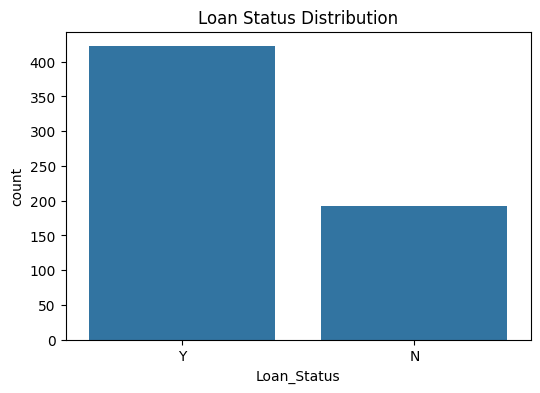

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x="Loan_Status", data=df)

plt.title("Loan Status Distribution")

plt.show()

df["Loan_Status"].value_counts(normalize=True)*100

##  Numerical Feature Analysis

Visualize the distribution of numerical features to identify skewness and unusual patterns.

In [10]:
num_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term"
]

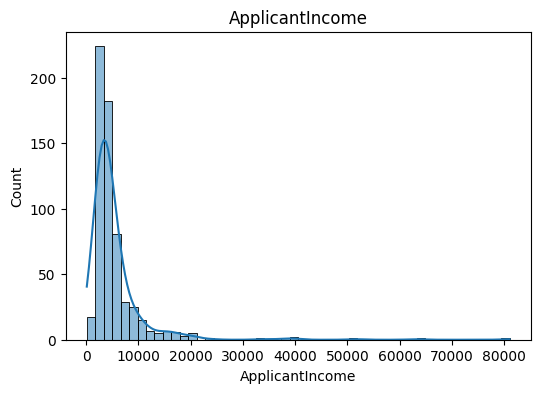

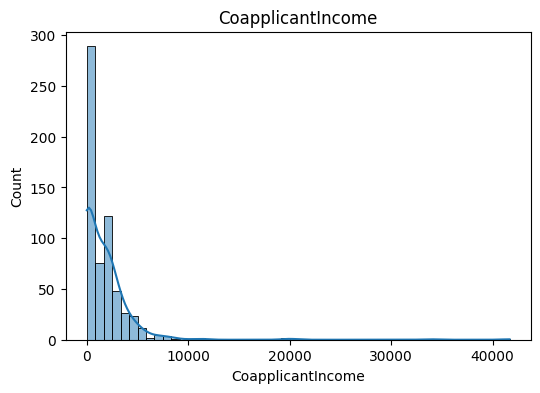

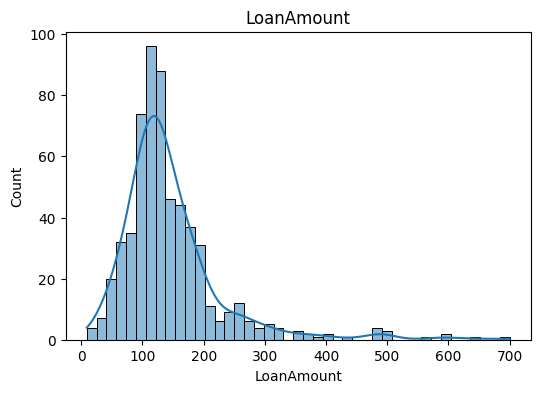

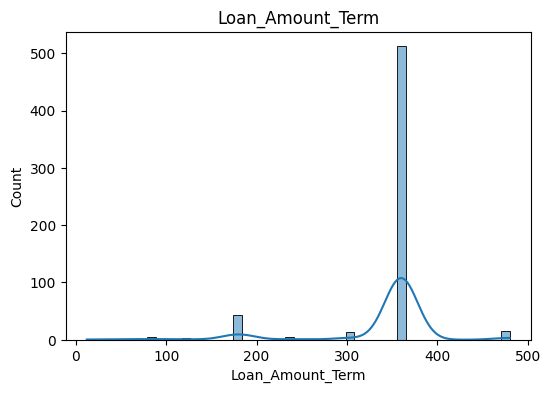

In [11]:
for col in num_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

##  Outlier Detection

Boxplots are used to identify potential outliers that may influence model performance.

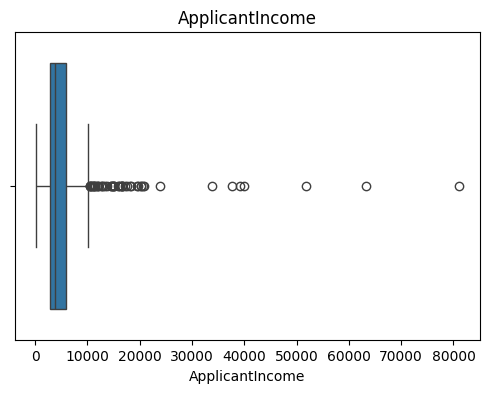

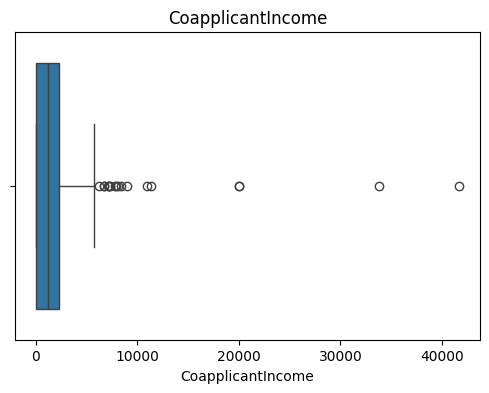

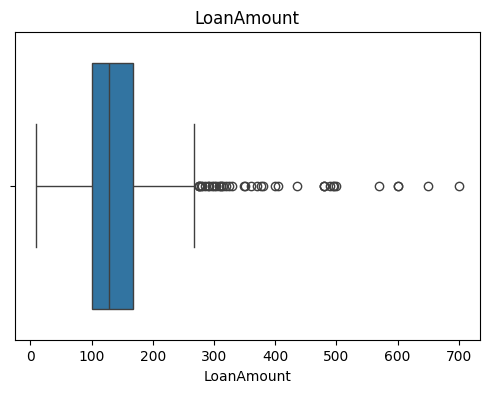

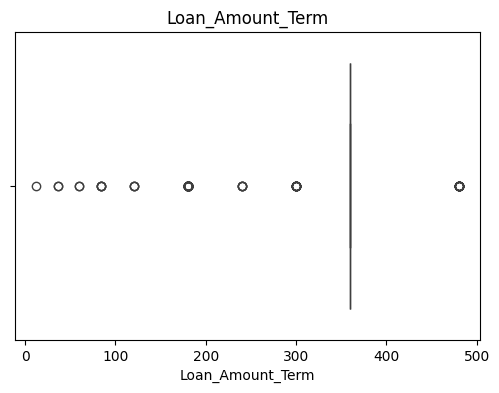

In [12]:
for col in num_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

##  Categorical Feature Analysis

Explore the distribution of categorical variables across the dataset.

In [13]:
cat_features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Credit_History",
    "Property_Area"
]

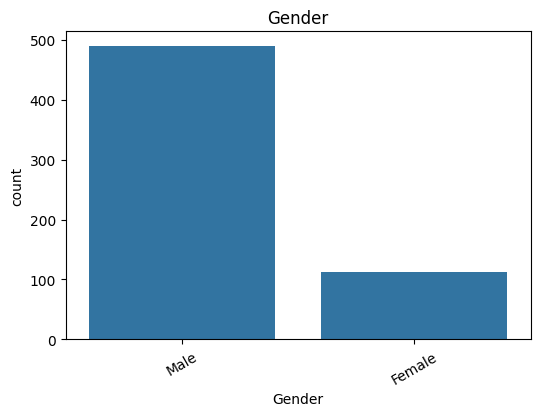

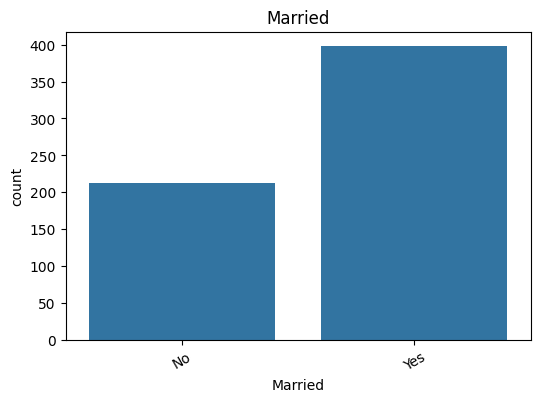

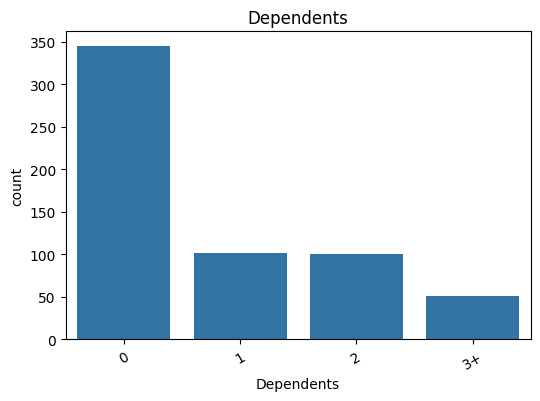

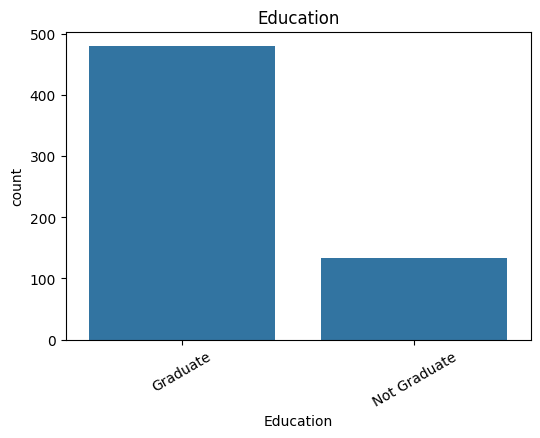

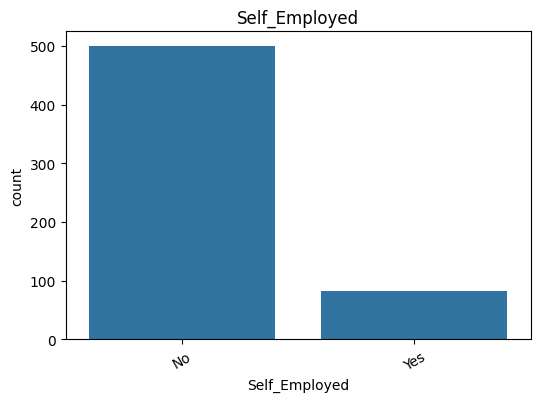

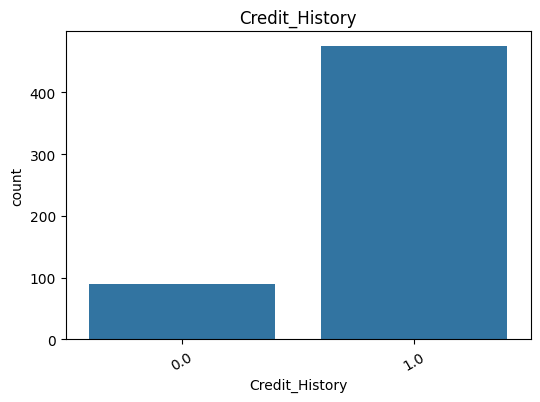

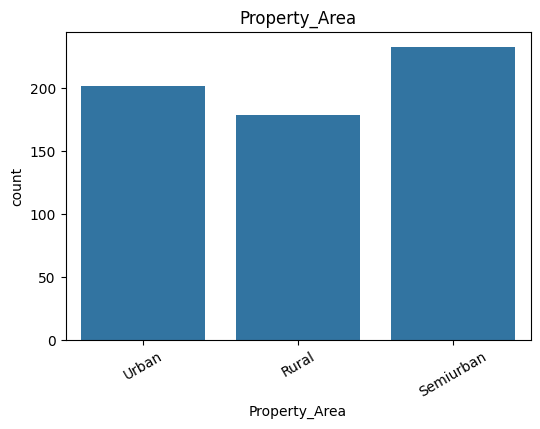

In [14]:
for col in cat_features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=30)
    plt.title(col)
    plt.show()

##  Relationship Between Features and Loan Approval

Analyze how different categorical variables influence loan approval outcomes.

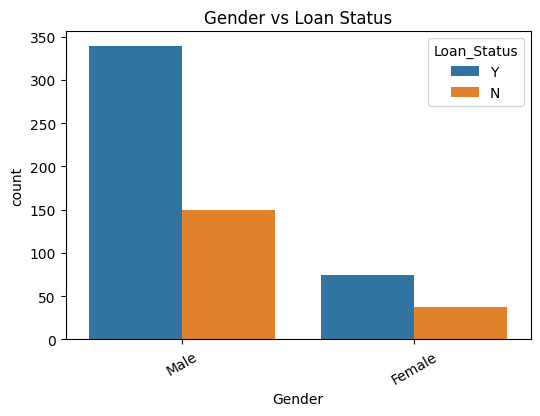

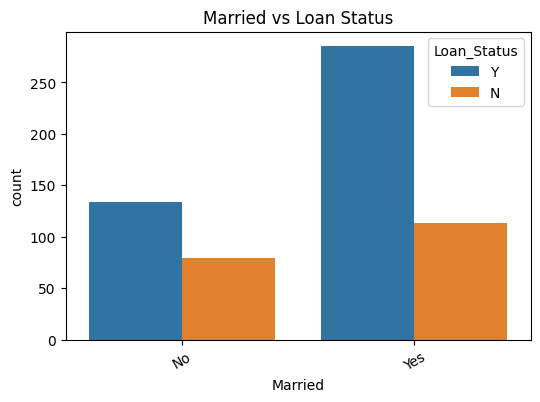

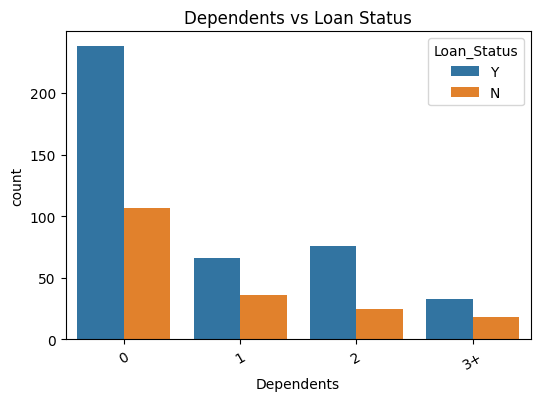

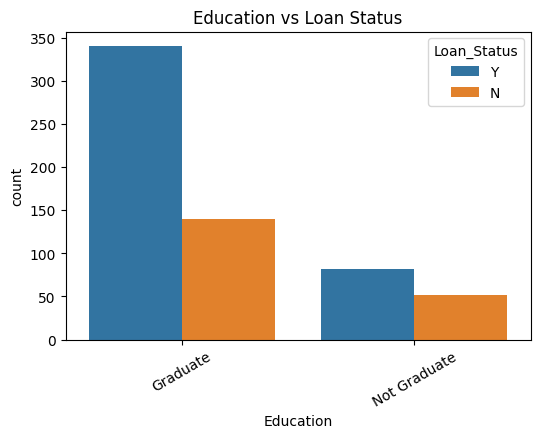

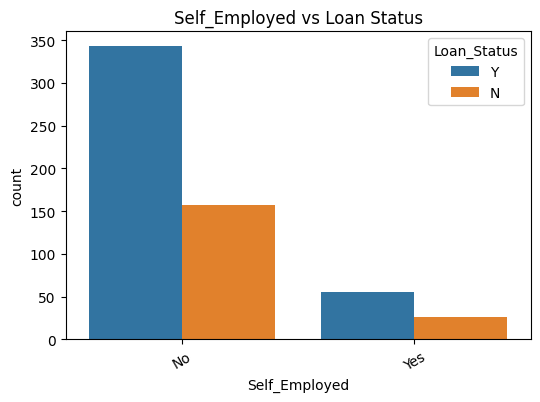

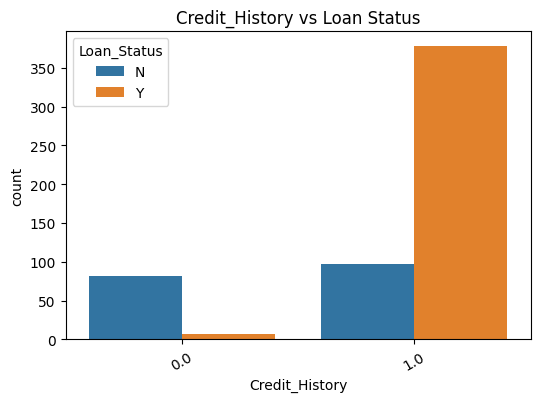

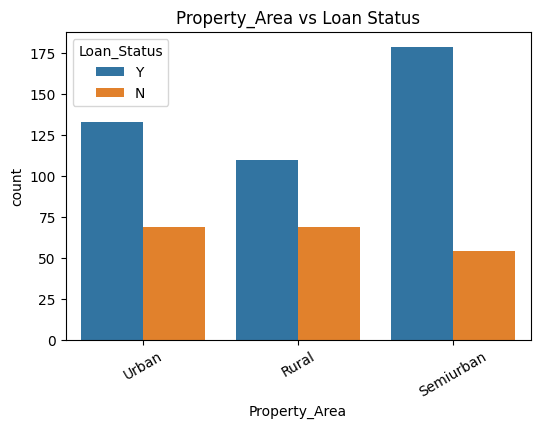

In [15]:
for col in cat_features:
    plt.figure(figsize=(6,4))
    sns.countplot(
        x=col,
        hue="Loan_Status",
        data=df
    )
    plt.xticks(rotation=30)
    plt.title(f"{col} vs Loan Status")
    plt.show()

##  Relationship Between Features and Loan Approval

Analyze how different categorical variables influence loan approval outcomes.

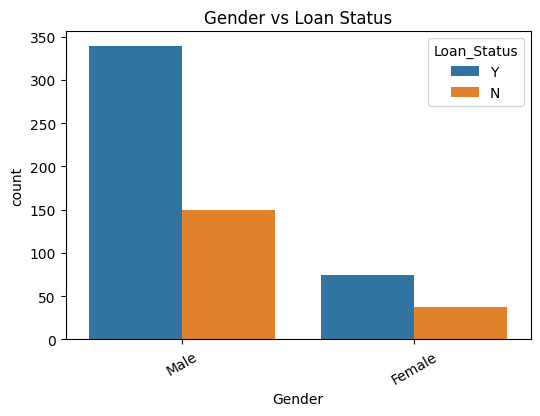

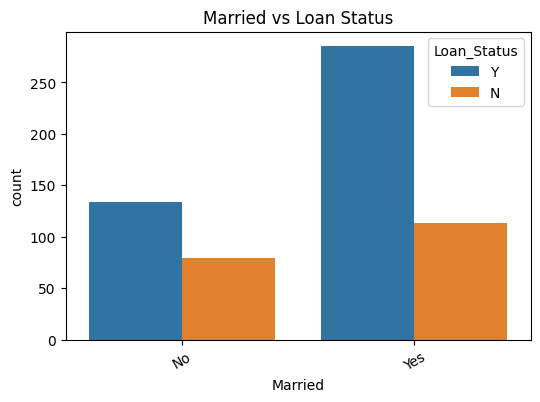

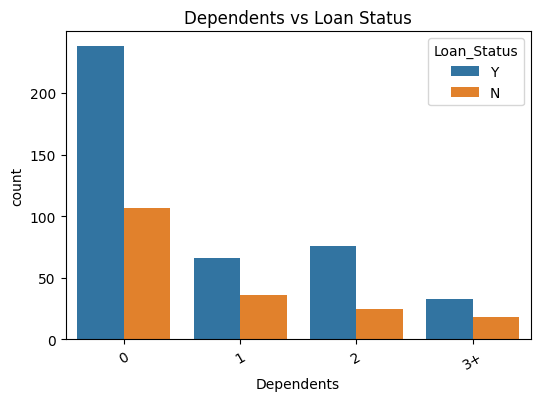

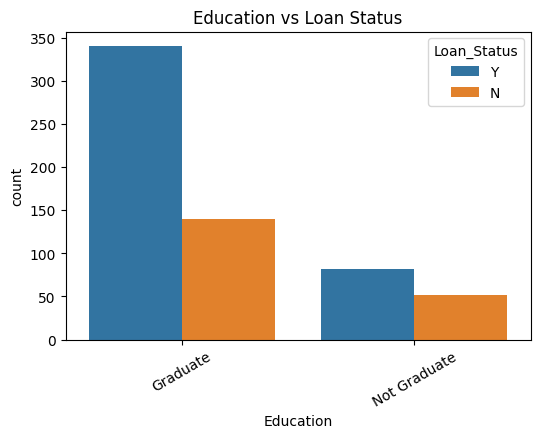

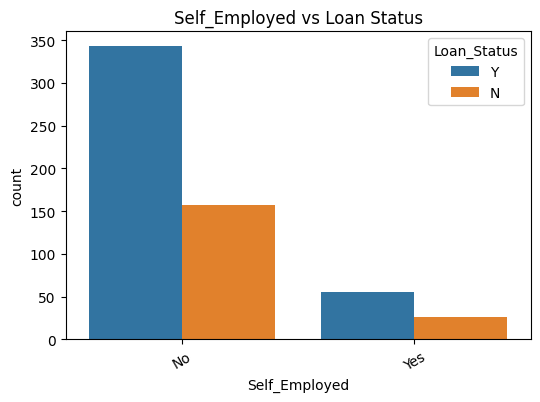

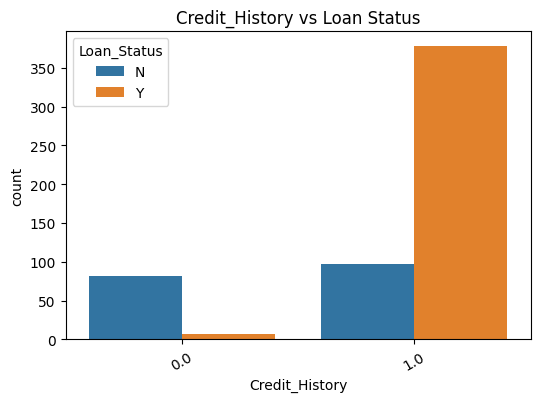

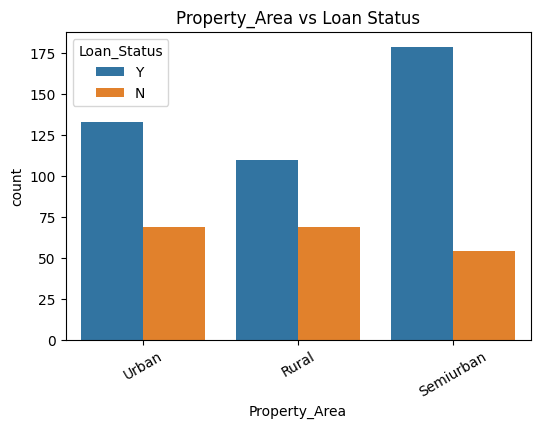

In [16]:
for col in cat_features:
    plt.figure(figsize=(6,4))
    sns.countplot(
        x=col,
        hue="Loan_Status",
        data=df
    )
    plt.xticks(rotation=30)
    plt.title(f"{col} vs Loan Status")
    plt.show()

##  Correlation Matrix

Visualize the relationships between numerical variables using a heatmap.

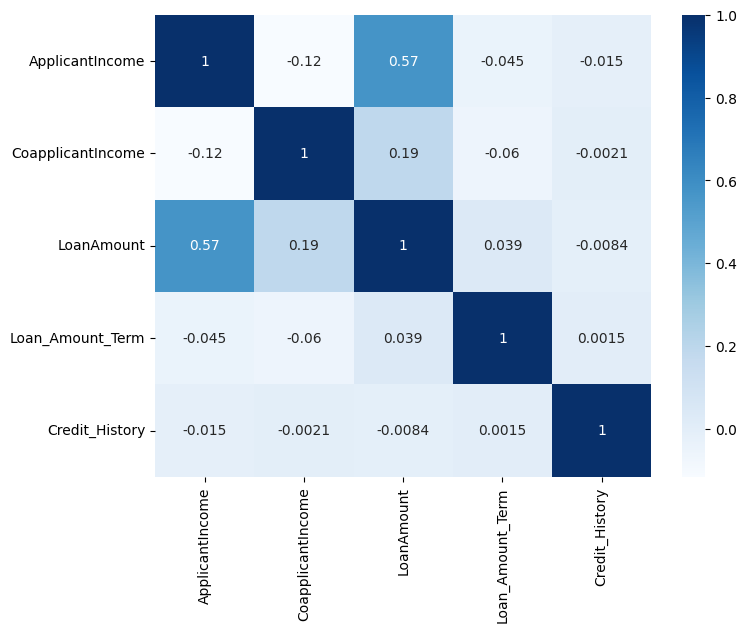

In [17]:
import numpy as np

plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="Blues"
)

plt.show()

#  Data Cleaning

This stage prepares the dataset for modeling by:

- Handling missing values
- Correcting data types
- Removing inconsistencies

In [18]:
df["Loan_Status"] = df["Loan_Status"].map({
    "Y":1,
    "N":0
})

#  Feature Engineering

Feature engineering creates new informative variables from existing data.

The following engineered features are introduced:

- Total Income
- Loan-Income Ratio
- Family Size
- Income Per Person
- Log-Transformed Applicant Income
- Log-Transformed Loan Amount

These features improve the model's ability to capture meaningful relationships within the data.

In [19]:
num_cols = [
    "LoanAmount",
    "Loan_Amount_Term"
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [20]:
cat_cols = [
    "Gender",
    "Married",
    "Dependents",
    "Self_Employed",
    "Credit_History"
]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [21]:
df["TotalIncome"] = (
    df["ApplicantIncome"] +
    df["CoapplicantIncome"]
)

In [22]:
df["LoanIncomeRatio"] = (
    df["LoanAmount"] /
    df["TotalIncome"]
)

In [23]:
df["Dependents"] = df["Dependents"].replace("3+","3")

df["Dependents"] = df["Dependents"].astype(int)

df["FamilySize"] = (
    df["Dependents"] + 1
)

In [24]:
df["IncomePerPerson"] = (
    df["TotalIncome"] /
    df["FamilySize"]
)

In [25]:
import numpy as np

df["ApplicantIncomeLog"] = np.log1p(df["ApplicantIncome"])

df["LoanAmountLog"] = np.log1p(df["LoanAmount"])

In [26]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanIncomeRatio,FamilySize,IncomePerPerson,ApplicantIncomeLog,LoanAmountLog
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1,5849.0,0.021884,1,5849.0,8.674197,4.859812
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0,6091.0,0.021015,2,3045.5,8.430327,4.859812
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1,3000.0,0.022000,1,3000.0,8.006701,4.204693
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1,4941.0,0.024287,1,4941.0,7.857094,4.795791
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1,6000.0,0.023500,1,6000.0,8.699681,4.955827


In [27]:
X = df.drop("Loan_Status",axis=1)
y = df["Loan_Status"]

In [28]:
num_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

cat_features = X.select_dtypes(
    include="object"
).columns.tolist()

print(num_features)
print(cat_features)

['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'TotalIncome', 'LoanIncomeRatio', 'FamilySize', 'IncomePerPerson', 'ApplicantIncomeLog', 'LoanAmountLog']
['Loan_ID', 'Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']


#  Data Preprocessing Pipeline

Machine Learning algorithms require numerical inputs.

A Scikit-learn Pipeline is used to ensure consistent preprocessing by:

- Encoding categorical variables
- Passing numerical variables
- Preventing data leakage

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            cat_features
        ),
        (
            "num",
            "passthrough",
            num_features
        )
    ]
)

##  Train-Test Split

Split the dataset into training and testing sets while preserving the target distribution using stratified sampling.

In [30]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#  Model Evaluation Framework

To ensure a fair comparison between models, a reusable evaluation function is created.

Each model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Cross Validation

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

results = []

In [32]:
def evaluate_model(name, model):

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_pred)

    cv_scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring="f1"
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "CV Mean": cv_scores.mean(),
        "CV Std": cv_scores.std()
    })

    return pipeline

#  Model Training

The following Machine Learning models are trained and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- Extra Trees Classifier
- AdaBoost Classifier
- Gradient Boosting Classifier
- HistGradient Boosting Classifier

In [33]:
from sklearn.linear_model import LogisticRegression

evaluate_model(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, random_state=42)
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Loan_ID', 'Gender',
                                                   'Married', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area']),
                                                 ('num', 'passthrough',
                                                  ['Dependents',
                                                   'ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History',
                                                   'TotalIncome',
                                                   'LoanIncomeRatio',
                                                   'FamilySize',
                                                   'IncomePerPerson',
                                                   'ApplicantIncomeLog',
                                                   'LoanAmountLog'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [34]:
from sklearn.tree import DecisionTreeClassifier

evaluate_model(
    "Decision Tree",
    DecisionTreeClassifier(random_state=42)
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Loan_ID', 'Gender',
                                                   'Married', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area']),
                                                 ('num', 'passthrough',
                                                  ['Dependents',
                                                   'ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History',
                                                   'TotalIncome',
                                                   'LoanIncomeRatio',
                                                   'FamilySize',
                                                   'IncomePerPerson',
                                                   'ApplicantIncomeLog',
                                                   'LoanAmountLog'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [35]:
from sklearn.ensemble import RandomForestClassifier
evaluate_model(
    "Random Forest",
    RandomForestClassifier(
        random_state=42,
        n_estimators=300,
        n_jobs=-1
    )
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Loan_ID', 'Gender',
                                                   'Married', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area']),
                                                 ('num', 'passthrough',
                                                  ['Dependents',
                                                   'ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History',
                                                   'TotalIncome',
                                                   'LoanIncomeRatio',
                                                   'FamilySize',
                                                   'IncomePerPerson',
                                                   'ApplicantIncomeLog',
                                                   'LoanAmountLog'])])),
                ('model',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [36]:
from sklearn.ensemble import ExtraTreesClassifier
evaluate_model(
    "Extra Trees Classifier",
    ExtraTreesClassifier(
        random_state=42,
        n_estimators=300,
        n_jobs=-1
    )
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Loan_ID', 'Gender',
                                                   'Married', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area']),
                                                 ('num', 'passthrough',
                                                  ['Dependents',
                                                   'ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History',
                                                   'TotalIncome',
                                                   'LoanIncomeRatio',
                                                   'FamilySize',
                                                   'IncomePerPerson',
                                                   'ApplicantIncomeLog',
                                                   'LoanAmountLog'])])),
                ('model',
                 ExtraTreesClassifier(n_estimators=300, n_jobs=-1,
                                      random_state=42))])

In [37]:
from sklearn.ensemble import AdaBoostClassifier
evaluate_model(
    "AdaBoost",
    AdaBoostClassifier(
        random_state=42,
        n_estimators=200
    )
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Loan_ID', 'Gender',
                                                   'Married', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area']),
                                                 ('num', 'passthrough',
                                                  ['Dependents',
                                                   'ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History',
                                                   'TotalIncome',
                                                   'LoanIncomeRatio',
                                                   'FamilySize',
                                                   'IncomePerPerson',
                                                   'ApplicantIncomeLog',
                                                   'LoanAmountLog'])])),
                ('model',
                 AdaBoostClassifier(n_estimators=200, random_state=42))])

In [38]:
from sklearn.ensemble import GradientBoostingClassifier

evaluate_model(
    "Gradient Boosting",
    GradientBoostingClassifier(
        random_state=42
    )
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Loan_ID', 'Gender',
                                                   'Married', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area']),
                                                 ('num', 'passthrough',
                                                  ['Dependents',
                                                   'ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History',
                                                   'TotalIncome',
                                                   'LoanIncomeRatio',
                                                   'FamilySize',
                                                   'IncomePerPerson',
                                                   'ApplicantIncomeLog',
                                                   'LoanAmountLog'])])),
                ('model', GradientBoostingClassifier(random_state=42))])

In [39]:
from sklearn.ensemble import HistGradientBoostingClassifier

evaluate_model(
    "HistGradient Boosting",
    HistGradientBoostingClassifier(
        random_state=42
    )
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Loan_ID', 'Gender',
                                                   'Married', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area']),
                                                 ('num', 'passthrough',
                                                  ['Dependents',
                                                   'ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History',
                                                   'TotalIncome',
                                                   'LoanIncomeRatio',
                                                   'FamilySize',
                                                   'IncomePerPerson',
                                                   'ApplicantIncomeLog',
                                                   'LoanAmountLog'])])),
                ('model', HistGradientBoostingClassifier(random_state=42))])

#  Model Comparison

Compare all trained models using multiple evaluation metrics to identify the best-performing classifier.

In [40]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="F1",
    ascending=False
)
results_df.reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,CV Mean,CV Std
0,AdaBoost,0.902439,0.884211,0.988235,0.933333,0.849381,0.871895,0.011945
1,Gradient Boosting,0.861789,0.861702,0.952941,0.905028,0.805418,0.869303,0.008629
2,Extra Trees Classifier,0.853659,0.831683,0.988235,0.903226,0.770433,0.870689,0.012287
3,Logistic Regression,0.853659,0.838384,0.976471,0.902174,0.777709,0.874233,0.016320
4,Random Forest,0.853659,0.838384,0.976471,0.902174,0.777709,0.866245,0.010805
5,HistGradient Boosting,0.821138,0.862069,0.882353,0.872093,0.783282,0.849398,0.017338
6,Decision Tree,0.780488,0.881579,0.788235,0.832298,0.775697,0.839772,0.030465


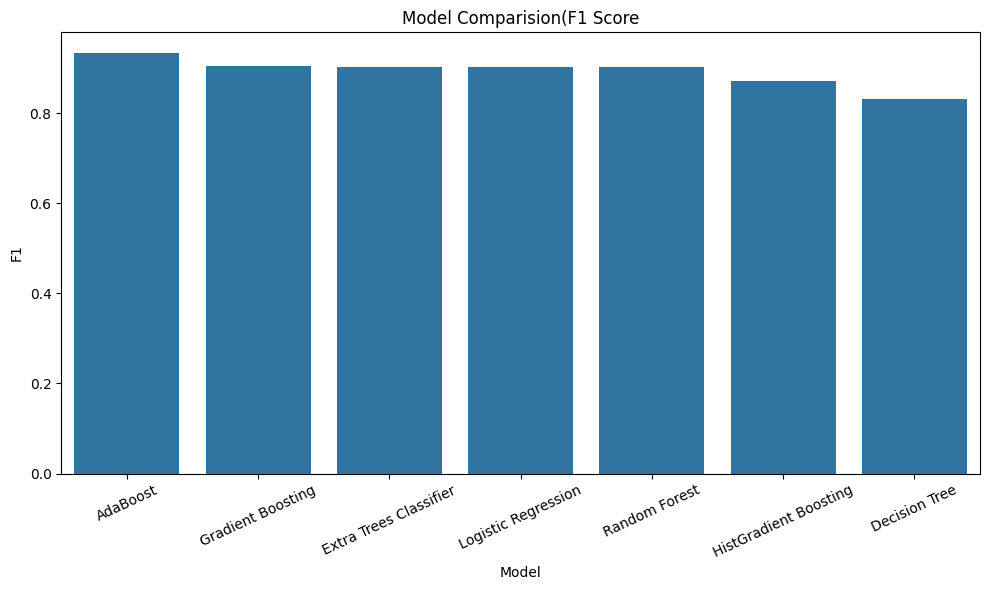

In [41]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=results_df,
    x="Model",
    y="F1"
)
plt.xticks(rotation=25)
plt.title("Model Comparision(F1 Score")
plt.tight_layout()
plt.show()

In [42]:
best_model = Pipeline([
    ("preprocessor",preprocessor),
    ("model", AdaBoostClassifier(
        random_state=42,
        n_estimators=200
    ))
])
best_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Loan_ID', 'Gender',
                                                   'Married', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area']),
                                                 ('num', 'passthrough',
                                                  ['Dependents',
                                                   'ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History',
                                                   'TotalIncome',
                                                   'LoanIncomeRatio',
                                                   'FamilySize',
                                                   'IncomePerPerson',
                                                   'ApplicantIncomeLog',
                                                   'LoanAmountLog'])])),
                ('model',
                 AdaBoostClassifier(n_estimators=200, random_state=42))])

In [43]:
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = best_model.named_steps[
    "model"
].feature_importances_

#  Feature Importance

Tree-based ensemble models provide feature importance scores, allowing us to understand which variables contribute the most to loan approval predictions.

In [44]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance":importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

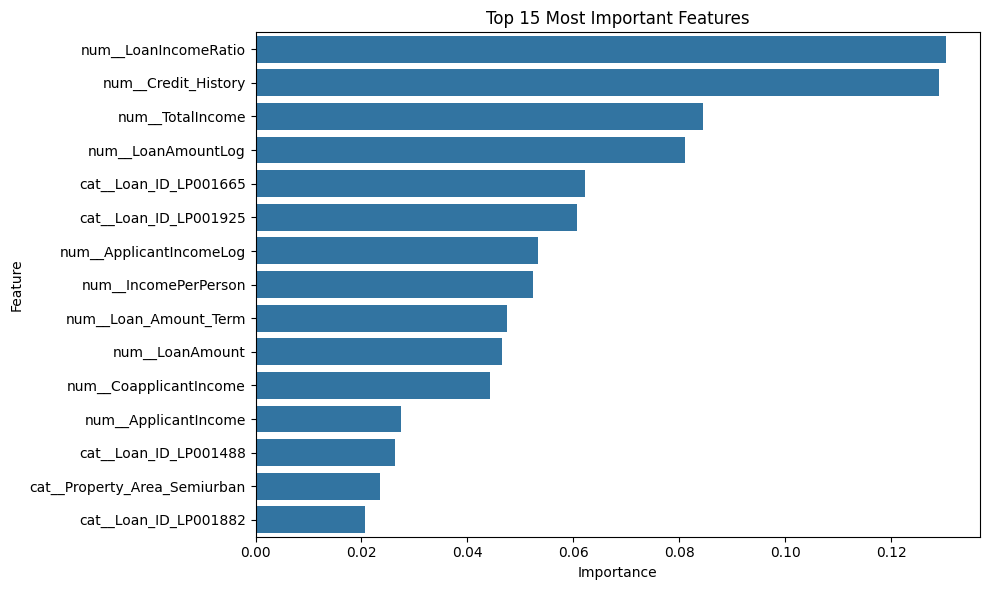

In [45]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Most Important Features")

plt.tight_layout()

plt.show()

#  Confusion Matrix

The confusion matrix provides a detailed summary of prediction outcomes by comparing actual and predicted loan approval decisions.

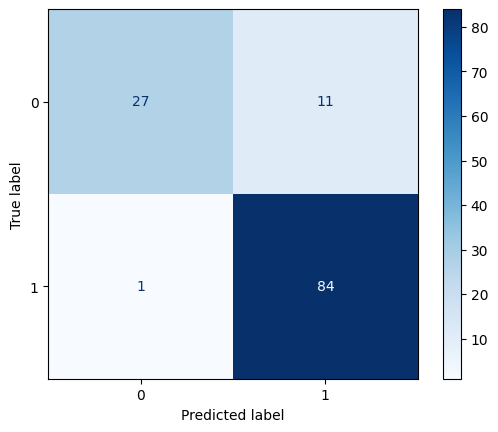

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.show()

#  ROC Curve

The ROC Curve measures the model's ability to distinguish between approved and rejected loan applications across different thresholds.

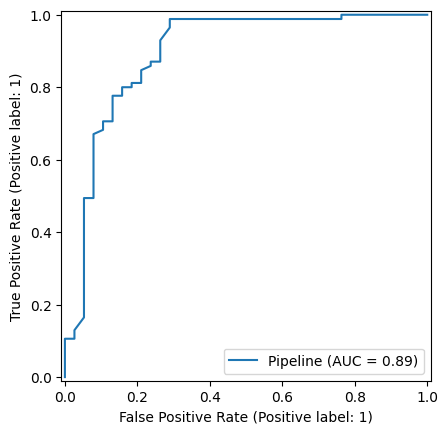

In [47]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.show()

#  Precision–Recall Curve

The Precision–Recall Curve illustrates the trade-off between Precision and Recall and is particularly useful for evaluating classification performance.

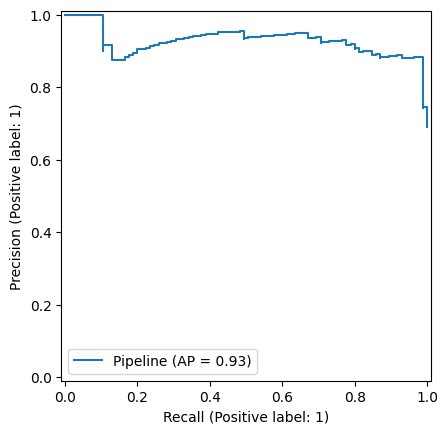

In [48]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.show()

#  Hyperparameter Tuning

RandomizedSearchCV is used to optimize the AdaBoost Classifier by searching multiple combinations of hyperparameters.

The objective is to improve the model's generalization performance.

In [49]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    "model__n_estimators":[50,100,200,300],
    "model__learning_rate":[0.01,0.05,0.1,0.5,1]
}

In [50]:
pipeline = Pipeline([
    ("preprocessor",preprocessor),
    ("model",AdaBoostClassifier(random_state=42))
])

In [51]:
search = RandomizedSearchCV(
    pipeline,
    param_grid,
    n_iter=10,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('cat',
                                                                               OneHotEncoder(handle_unknown='ignore',
                                                                                             sparse_output=False),
                                                                               ['Loan_ID',
                                                                                'Gender',
                                                                                'Married',
                                                                                'Education',
                                                                                'Self_Employed',
                                                                                'Property_Area']),
                                                                              ('num',
                                                                               'passthrough',
                                                                               ['Dependents',
                                                                                'ApplicantIncome',
                                                                                'CoapplicantIncome',
                                                                                'LoanAmount',
                                                                                'Loan_Amount_Term',
                                                                                'Credit_History',
                                                                                'TotalIncome',
                                                                                'LoanIncomeRatio',
                                                                                'FamilySize',
                                                                                'IncomePerPerson',
                                                                                'ApplicantIncomeLog',
                                                                                'LoanAmountLog'])])),
                                             ('model',
                                              AdaBoostClassifier(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.01, 0.05,
                                                                 0.1, 0.5, 1],
                                        'model__n_estimators': [50, 100, 200,
                                                                300]},
                   random_state=42, scoring='f1')

In [52]:
search.best_params_

{'model__n_estimators': 50, 'model__learning_rate': 0.01}

In [53]:
search.best_score_

np.float64(0.8699456484348126)

#  Best Model Evaluation

Evaluate the optimized model using the test dataset and report the final performance metrics.

In [54]:
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)

print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall   :",recall_score(y_test,y_pred))
print("F1 Score :",f1_score(y_test,y_pred))

Accuracy : 0.8536585365853658
Precision: 0.8316831683168316
Recall   : 0.9882352941176471
F1 Score : 0.9032258064516129


#  Save Trained Model

The final optimized model is saved using Joblib for future inference and deployment.

In [55]:
import joblib

joblib.dump(
    best_model,
    "loan_approval_model.pkl"
)

['loan_approval_model.pkl']

#  Conclusion

This project demonstrated a complete Machine Learning pipeline for loan approval prediction using Ensemble Learning techniques.

### Key Highlights

- Performed comprehensive Exploratory Data Analysis
- Engineered meaningful predictive features
- Built a preprocessing pipeline
- Compared seven classification algorithms
- Tuned the best-performing model
- Explained predictions using feature importance

###  Best Performing Model

**AdaBoost Classifier**

The optimized AdaBoost model achieved the highest overall performance, making it the preferred model for this dataset.

This project demonstrates the practical application of Ensemble Learning techniques for real-world financial classification problems.